In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/factory-oee-and-downtime-synthetic-starter-dataset/cover.png
/kaggle/input/factory-oee-and-downtime-synthetic-starter-dataset/LICENSE
/kaggle/input/factory-oee-and-downtime-synthetic-starter-dataset/README.md
/kaggle/input/factory-oee-and-downtime-synthetic-starter-dataset/dataset-metadata.json


# Factory OEE & Downtime — a Beginner’s Guide (Synthetic, No Internet)

## Cell 1 — Changelog (Markdown)
Use this cell to track your changes version-to-version. Add one line per update so readers know what changed and you can compare CV → LB later.


In [2]:
# Repro
SEED = 1337
import os, random, math, datetime as dt
import numpy as np, pandas as pd
random.seed(SEED); np.random.seed(SEED)

# Paths
WORK = "/kaggle/working"
os.makedirs(WORK, exist_ok=True)

print("SEED:", SEED)
print("Work dir:", WORK)


SEED: 1337
Work dir: /kaggle/working


## Cell 2 — Repro & Imports
Set a global **SEED** and import essentials.  
Why this matters: deterministic runs → easier debugging & apples-to-apples comparisons. Also make a `/kaggle/working` folder for outputs.


In [3]:
# Simulation horizon: 3 days, per-minute resolution (fixed: use "min" not "T")
DAYS = 3
FREQ = "min"  # minute frequency; future-proof

start = pd.Timestamp("2025-01-01 06:00:00")  # start at shift A
end = start + pd.Timedelta(days=DAYS)
time_index = pd.date_range(start, end, freq=FREQ, inclusive="left")

# 3 shifts of 8h covering 24h
def shift_name(ts):
    h = ts.hour
    if 6 <= h < 14:
        return "A"   # 06:00–14:00
    if 14 <= h < 22:
        return "B"   # 14:00–22:00
    return "C"      # 22:00–06:00

calendar = pd.DataFrame({
    "timestamp": time_index,
    "shift": [shift_name(ts) for ts in time_index]
})
calendar["day"] = calendar["timestamp"].dt.date

# Quick sanity check
print("Rows in calendar:", len(calendar))
print(calendar.head(3))


Rows in calendar: 4320


            timestamp shift         day
0 2025-01-01 06:00:00     A  2025-01-01
1 2025-01-01 06:01:00     A  2025-01-01
2 2025-01-01 06:02:00     A  2025-01-01


## Cell 3 — Settings & Shift Calendar
Create a **time index** (per-minute) for several days and map each timestamp to a **shift** (A/B/C) and **day**.  
This gives us a clean calendar to aggregate OEE by shift/day later.

In [4]:
# We simulate one line with 2 machines (M1, M2) and modeled downtimes.
MACHINES = ["M1", "M2"]

DOWNTIME_CAUSES = [
    "Mechanical", "Electrical", "Changeover", "Blocked", "Starved", "Quality"
]

def synth_machine(machine, base_rate=6, scrap_rate=0.02,
                  fail_probs={"Mechanical":0.0009,"Electrical":0.0006,"Changeover":0.0007,
                              "Blocked":0.0006,"Starved":0.0006,"Quality":0.0005},
                  down_len=(5, 40)):
    """
    Return per-minute time series for one machine:
    - is_running
    - units (actual output)
    - cause markers
    - scrap
    """
    df = pd.DataFrame({"timestamp": time_index})
    df["machine"] = machine
    df["is_running"] = 1
    for c in DOWNTIME_CAUSES:
        df[f"cause_{c}"] = 0

    # introduce random downtime blocks by cause
    i = 0
    n = len(df)
    while i < n:
        # independent cause trigger probabilities
        cause_triggers = [(c, np.random.rand() < fail_probs[c]) for c in DOWNTIME_CAUSES]
        fired = [c for c, hit in cause_triggers if hit]
        if fired and df.loc[i, "is_running"] == 1:
            cause = np.random.choice(fired)
            L = np.random.randint(down_len[0], down_len[1])  # minutes down
            j = min(i+L, n)
            df.loc[i:j, "is_running"] = 0
            df.loc[i, f"cause_{cause}"] = 1  # mark start
            i = j
        else:
            i += 1

    # production: Poisson when running, else 0; small shift-based rate drift
    rate_shift = df["timestamp"].dt.hour.map(lambda h: 0.5 if h in [6,14,22] else 0.0)  # slightly higher at shift start
    lam = base_rate + rate_shift.values
    df["units"] = np.where(df["is_running"]==1, np.random.poisson(lam), 0)

    # scrap generation
    df["scrap"] = (np.random.rand(n) < scrap_rate).astype(int) * (df["units"]>0).astype(int)
    df["good_units"] = df["units"] - df["scrap"]

    return df

raw = pd.concat([synth_machine(m) for m in MACHINES], ignore_index=True)
raw = raw.merge(calendar, on="timestamp", how="left")
raw = raw.sort_values(["timestamp","machine"]).reset_index(drop=True)

print("Rows:", len(raw))
raw.head()


Rows: 8640


,timestamp,machine,is_running,cause_Mechanical,cause_Electrical,cause_Changeover,cause_Blocked,cause_Starved,cause_Quality,units,scrap,good_units,shift,day
0,2025-01-01 06:00:00,M1,1,0,0,0,0,0,0,7,0,7,A,2025-01-01
1,2025-01-01 06:00:00,M2,1,0,0,0,0,0,0,6,0,6,A,2025-01-01
2,2025-01-01 06:01:00,M1,1,0,0,0,0,0,0,10,0,10,A,2025-01-01
3,2025-01-01 06:01:00,M2,1,0,0,0,0,0,0,7,0,7,A,2025-01-01
4,2025-01-01 06:02:00,M1,1,0,0,0,0,0,0,6,0,6,A,2025-01-01


## Cell 4 — Synthetic Line & Downtime Generator
Simulate 2 machines:
- Random **downtime blocks** with labeled causes (Mechanical, Electrical, etc.).
- **Units/min** only when running; add a small shift-start rate bump.
- **Scrap** events to enable Quality calculations.

Outputs: a tidy table with `timestamp, machine, is_running, units, scrap, good_units, shift, day`.


In [5]:
# OEE definitions:
# Availability = running_time / planned_time
# Performance  = actual_output / (ideal_rate * running_time)
# Quality      = good_units / total_units
# OEE          = A * P * Q

IDEAL_RATE = 6  # ideal units per minute when running (assumption)

def _oee_from_agg(df, ideal_rate=IDEAL_RATE):
    df = df.copy()
    df["availability"] = np.where(df["planned_min"] > 0,
                                  df["running_min"] / df["planned_min"], 0.0)
    df["performance"]  = np.where(df["running_min"] > 0,
                                  df["total_units"] / (ideal_rate * df["running_min"]), 0.0)
    df["quality"]      = np.where(df["total_units"] > 0,
                                  df["good_units"] / df["total_units"], 0.0)
    df["oee"] = df["availability"] * df["performance"] * df["quality"]
    return df

# ---- OEE by machine × day × shift (no .apply, so no FutureWarning) ----
oee_shift = (
    raw.groupby(["machine", "day", "shift"], as_index=False)
       .agg(planned_min=("is_running", "size"),
            running_min=("is_running", "sum"),
            total_units=("units", "sum"),
            good_units=("good_units", "sum"))
)
oee_shift = _oee_from_agg(oee_shift, ideal_rate=IDEAL_RATE)
oee_shift = oee_shift.sort_values(["machine", "day", "shift"]).reset_index(drop=True)

# ---- OEE by machine × day ----
oee_day = (
    raw.groupby(["machine", "day"], as_index=False)
       .agg(planned_min=("is_running", "size"),
            running_min=("is_running", "sum"),
            total_units=("units", "sum"),
            good_units=("good_units", "sum"))
)
oee_day = _oee_from_agg(oee_day, ideal_rate=IDEAL_RATE)
oee_day = oee_day.sort_values(["machine", "day"]).reset_index(drop=True)

# Save
oee_shift.to_csv(f"{WORK}/oee_by_shift.csv", index=False)
oee_day.to_csv(f"{WORK}/oee_by_day.csv", index=False)
print("Saved:", f"{WORK}/oee_by_shift.csv", "and", f"{WORK}/oee_by_day.csv")

# Quick peek
oee_day.head()


Saved: /kaggle/working/oee_by_shift.csv and /kaggle/working/oee_by_day.csv


,machine,day,planned_min,running_min,total_units,good_units,availability,performance,quality,oee
0,M1,2025-01-01,1080,975,5874,5851,0.902778,1.004103,0.996084,0.902932
1,M1,2025-01-02,1440,1285,7861,7837,0.892361,1.019585,0.996947,0.907060
2,M1,2025-01-03,1440,1201,7207,7185,0.834028,1.000139,0.996947,0.831597
3,M1,2025-01-04,360,306,1869,1862,0.850000,1.017974,0.996255,0.862037
4,M2,2025-01-01,1080,1046,6354,6336,0.968519,1.012428,0.997167,0.977778


## Cell 5 — OEE Calculation (Day & Shift)

Compute:
- **Availability** = running_time / planned_time
- **Performance** = actual_output / (ideal_rate * running_time)
- **Quality** = good_output / total_output  
Then **OEE = A * P * Q**.

We summarize by **machine × day** and **machine × day × shift**, and save to CSV.


In [6]:
# --- Robust downtime interval extraction + Pareto (safe on empty) ---

def intervals_from_flags(df, cause_col="cause_Mechanical"):
    """
    Build [start,end,duration] intervals for one machine-day slice.
    Assumes df has columns: ['timestamp','is_running', cause_col]
    The cause_col is a start flag; the interval runs until is_running returns to 1.
    """
    starts = df.index[df[cause_col] == 1].tolist()
    intervals = []
    n = len(df)
    for s in starts:
        # begin at s, advance at least one minute
        e = min(s + 1, n)
        # extend while down
        while e < n and df.loc[e, "is_running"] == 0:
            e += 1
        dur = max(0, e - s)  # minutes (0 is possible if flags exist but no down)
        # Guard: require positive duration to count as downtime
        if dur > 0:
            ts_start = df.loc[s, "timestamp"]
            ts_end   = df.loc[e - 1, "timestamp"]
            intervals.append((ts_start, ts_end, dur))
    return intervals

rows = []
for (m, d), g in raw.groupby(["machine", "day"], sort=False):
    # Ensure row order is chronological within the slice
    g = g.sort_values("timestamp").reset_index(drop=True)
    for cause in DOWNTIME_CAUSES:
        cause_col = f"cause_{cause}"
        if cause_col not in g.columns:
            continue  # skip unknown cause columns
        for (ts_start, ts_end, minutes) in intervals_from_flags(g, cause_col=cause_col):
            rows.append({
                "machine": m,
                "day": d,
                "cause": cause,
                "start": ts_start,
                "end": ts_end,
                "minutes": int(minutes)
            })

# Create DataFrame with explicit columns so it's valid even if rows == []
downtime_cols = ["machine", "day", "cause", "start", "end", "minutes"]
downtime = pd.DataFrame(rows, columns=downtime_cols)

# Build Pareto safely (empty-friendly)
if len(downtime) == 0:
    pareto = pd.DataFrame(columns=["machine", "day", "cause", "minutes"])
    print("[INFO] No downtime intervals were detected; Pareto will be empty.")
else:
    pareto = (
        downtime.groupby(["machine", "day", "cause"], as_index=False)["minutes"]
        .sum()
        .sort_values(["machine", "day", "minutes"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

# Save and preview
pareto.to_csv(f"{WORK}/downtime_pareto.csv", index=False)
print("Saved:", f"{WORK}/downtime_pareto.csv")
pareto.head(10)


Saved: /kaggle/working/downtime_pareto.csv


,machine,day,cause,minutes
0,M1,2025-01-01,Starved,48
1,M1,2025-01-01,Changeover,38
2,M1,2025-01-01,Mechanical,19
3,M1,2025-01-02,Mechanical,55
4,M1,2025-01-02,Quality,38
5,M1,2025-01-02,Starved,36
6,M1,2025-01-02,Electrical,26
7,M1,2025-01-03,Starved,83
8,M1,2025-01-03,Changeover,53
9,M1,2025-01-03,Electrical,53


In [7]:
# Cell 6 — Downtime Durations & Pareto
# Convert "cause start" flags into actual downtime intervals (start -> end) and sum minutes by cause.
# Then build a Pareto table (descending minutes) by machine/day.

def intervals_from_flags(df, cause_col="cause_Mechanical"):
    """
    Build [start, end, duration_minutes] intervals for one machine-day slice.
    Assumes columns: ['timestamp','is_running', cause_col].
    The cause_col marks the start of a downtime; the interval continues until is_running returns to 1.
    """
    starts = df.index[df[cause_col] == 1].tolist()
    intervals = []
    n = len(df)
    for s in starts:
        # start at s, advance at least one minute
        e = min(s + 1, n)
        # extend while down
        while e < n and df.loc[e, "is_running"] == 0:
            e += 1
        dur = max(0, e - s)  # minutes
        if dur > 0:
            ts_start = df.loc[s, "timestamp"]
            ts_end   = df.loc[e - 1, "timestamp"]
            intervals.append((ts_start, ts_end, dur))
    return intervals

rows = []
for (m, d), g in raw.groupby(["machine", "day"], sort=False):
    # ensure chronological order within each slice
    g = g.sort_values("timestamp").reset_index(drop=True)
    for cause in DOWNTIME_CAUSES:
        cause_col = f"cause_{cause}"
        if cause_col not in g.columns:
            continue
        for (ts_start, ts_end, minutes) in intervals_from_flags(g, cause_col=cause_col):
            rows.append({
                "machine": m,
                "day": d,
                "cause": cause,
                "start": ts_start,
                "end": ts_end,
                "minutes": int(minutes)
            })

# Create DataFrame with explicit columns so it's valid even if no rows were found
downtime_cols = ["machine", "day", "cause", "start", "end", "minutes"]
downtime = pd.DataFrame(rows, columns=downtime_cols)

# Build Pareto safely (works even if downtime is empty)
if len(downtime) == 0:
    pareto = pd.DataFrame(columns=["machine", "day", "cause", "minutes"])
    print("[INFO] No downtime intervals were detected; Pareto is empty.")
else:
    pareto = (
        downtime.groupby(["machine", "day", "cause"], as_index=False)["minutes"]
        .sum()
        .sort_values(["machine", "day", "minutes"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

pareto.to_csv(f"{WORK}/downtime_pareto.csv", index=False)
print("Saved:", f"{WORK}/downtime_pareto.csv")
pareto.head(10)



Saved: /kaggle/working/downtime_pareto.csv


,machine,day,cause,minutes
0,M1,2025-01-01,Starved,48
1,M1,2025-01-01,Changeover,38
2,M1,2025-01-01,Mechanical,19
3,M1,2025-01-02,Mechanical,55
4,M1,2025-01-02,Quality,38
5,M1,2025-01-02,Starved,36
6,M1,2025-01-02,Electrical,26
7,M1,2025-01-03,Starved,83
8,M1,2025-01-03,Changeover,53
9,M1,2025-01-03,Electrical,53


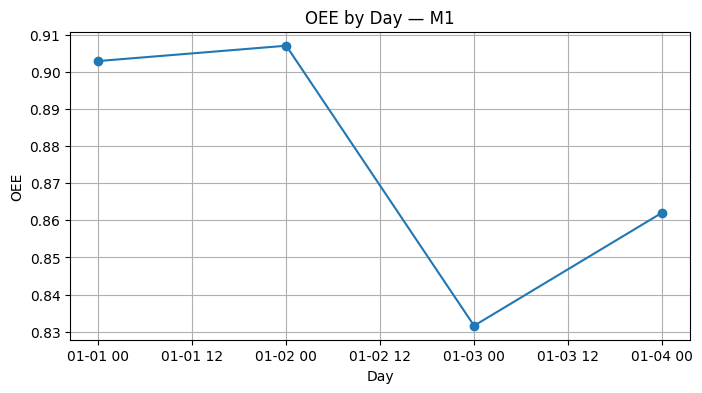

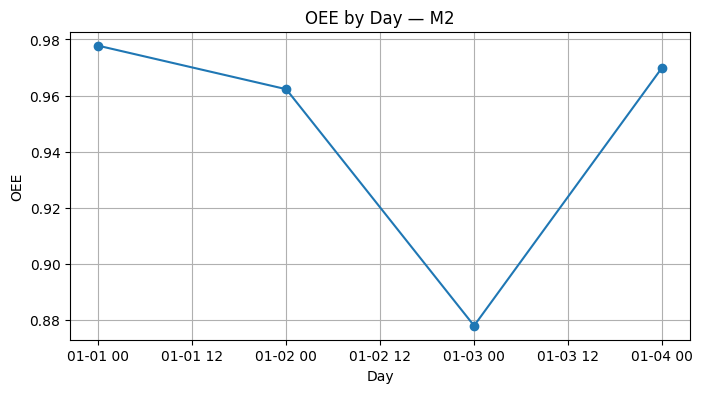

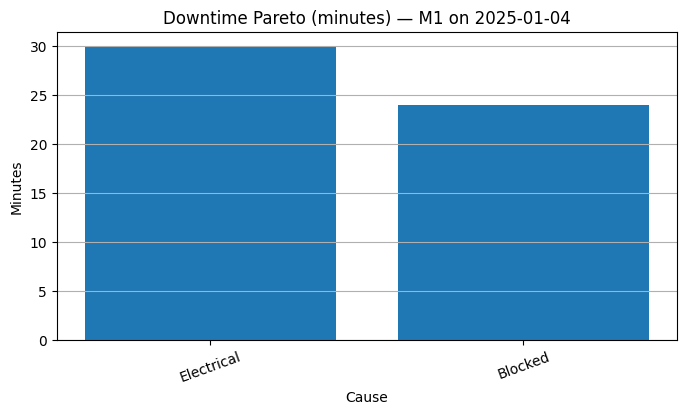

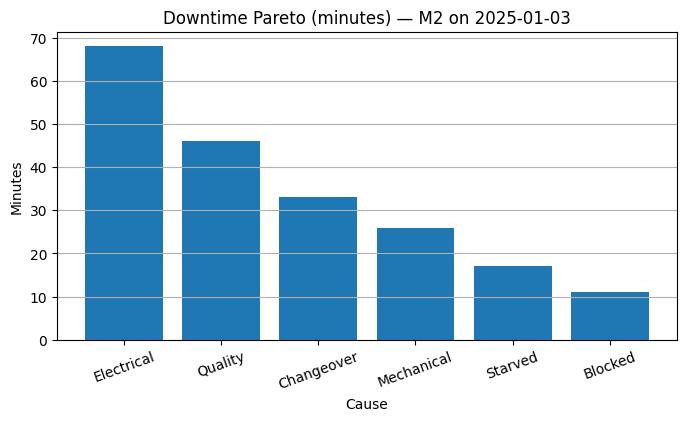

In [8]:
import matplotlib.pyplot as plt

# OEE by day
for m, g in oee_day.groupby("machine"):
    fig = plt.figure(figsize=(8,4))
    plt.plot(pd.to_datetime(g["day"]), g["oee"], marker="o")
    plt.title(f"OEE by Day — {m}")
    plt.xlabel("Day"); plt.ylabel("OEE")
    plt.grid(True)
    fig.savefig(f"{WORK}/oee_by_day_{m}.png", bbox_inches="tight")
    plt.show()

# Pareto: take latest day per machine and show top 6
latest_per_machine = pareto.groupby("machine")["day"].max().reset_index()
for _, row in latest_per_machine.iterrows():
    m, d = row["machine"], row["day"]
    g = pareto[(pareto["machine"]==m) & (pareto["day"]==d)]
    fig = plt.figure(figsize=(8,4))
    plt.bar(g["cause"], g["minutes"])
    plt.title(f"Downtime Pareto (minutes) — {m} on {d}")
    plt.xlabel("Cause"); plt.ylabel("Minutes")
    plt.xticks(rotation=20)
    plt.grid(True, axis="y")
    fig.savefig(f"{WORK}/pareto_{m}_{d}.png", bbox_inches="tight")
    plt.show()


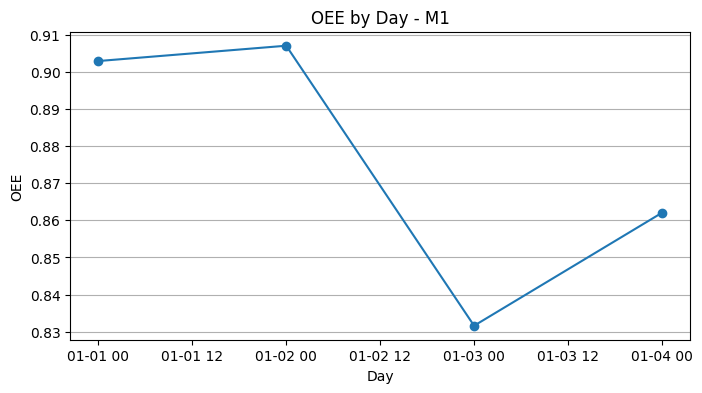

Saved: /kaggle/working/oee_by_day_M1.png


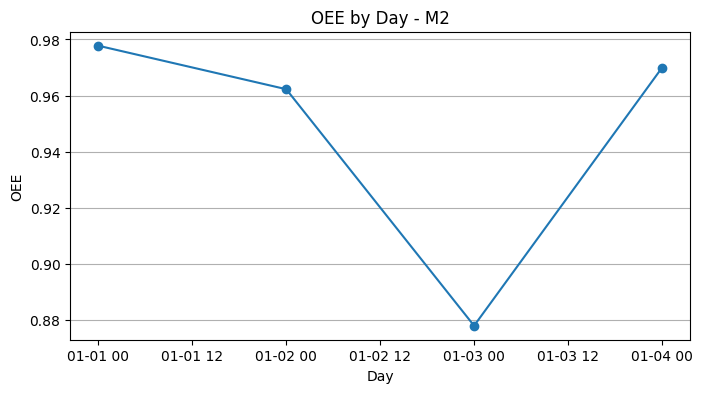

Saved: /kaggle/working/oee_by_day_M2.png


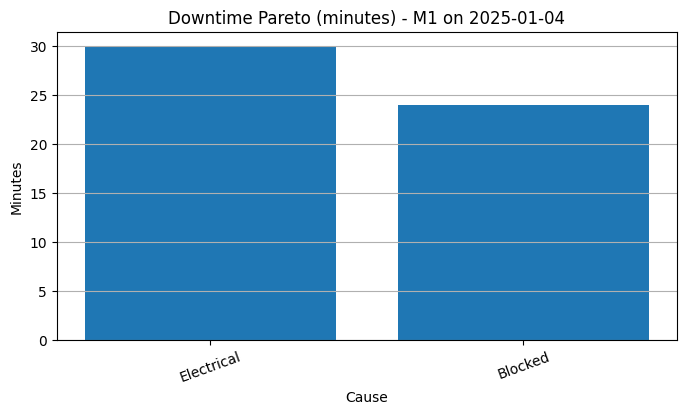

Saved: /kaggle/working/pareto_M1_2025-01-04.png


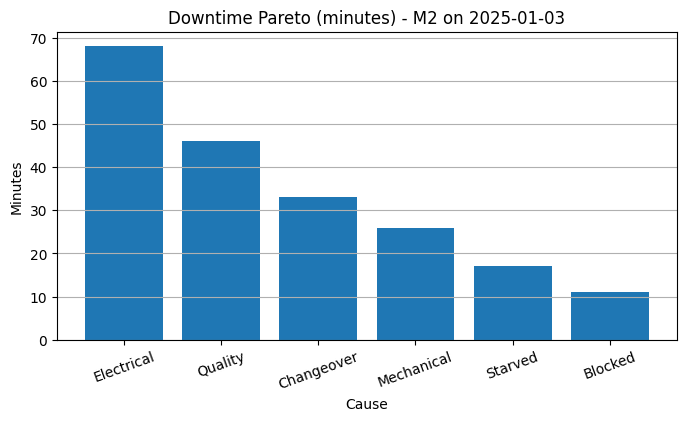

Saved: /kaggle/working/pareto_M2_2025-01-03.png


In [9]:
# Cell 7 — Quick Plots (OEE & Pareto)
# 1) OEE by day per machine (line)
# 2) Downtime Pareto (bar) for the latest day per machine
# Figures are saved to /kaggle/working as PNGs.

import matplotlib.pyplot as plt

# ---- OEE by day line plots ----
if "oee_day" not in globals() or oee_day.empty:
    print("[INFO] oee_day is missing or empty; skipping OEE plots.")
else:
    od = oee_day.copy()
    # Ensure 'day' is datetime-like for plotting
    od["day_dt"] = pd.to_datetime(od["day"])
    for m, g in od.groupby("machine"):
        fig = plt.figure(figsize=(8, 4))
        plt.plot(g["day_dt"], g["oee"], marker="o")
        plt.title(f"OEE by Day - {m}")
        plt.xlabel("Day")
        plt.ylabel("OEE")
        plt.grid(True, axis="y")
        save_path = f"{WORK}/oee_by_day_{m}.png"
        fig.savefig(save_path, bbox_inches="tight")
        plt.show()
        print("Saved:", save_path)

# ---- Downtime Pareto bar charts (latest day per machine) ----
if "pareto" not in globals() or pareto.empty:
    print("[INFO] pareto is missing or empty; skipping Pareto plots.")
else:
    pr = pareto.copy()
    # Normalize 'day' to datetime for comparison/labeling
    pr["day_dt"] = pd.to_datetime(pr["day"])
    latest = pr.groupby("machine", as_index=False)["day_dt"].max()
    for _, row in latest.iterrows():
        m = row["machine"]
        d = row["day_dt"]
        g = pr[(pr["machine"] == m) & (pr["day_dt"] == d)].copy()
        g = g.sort_values("minutes", ascending=False)
        fig = plt.figure(figsize=(8, 4))
        plt.bar(g["cause"], g["minutes"])
        plt.title(f"Downtime Pareto (minutes) - {m} on {d.date()}")
        plt.xlabel("Cause")
        plt.ylabel("Minutes")
        plt.xticks(rotation=20)
        plt.grid(True, axis="y")
        save_path = f"{WORK}/pareto_{m}_{d.date()}.png"
        fig.savefig(save_path, bbox_inches="tight")
        plt.show()
        print("Saved:", save_path)


## Cell 8 — Simple SPC: X-bar / R
Create hourly **subgroups** on running minutes and compute:
- **X̄** (mean units/min),
- **s** (std dev),
- **R** (range).

Plot **X̄** over time to spot shifts or instability. Save `spc_xbar_r.csv` for downstream dashboards.


Saved: /kaggle/working/spc_xbar_r.csv


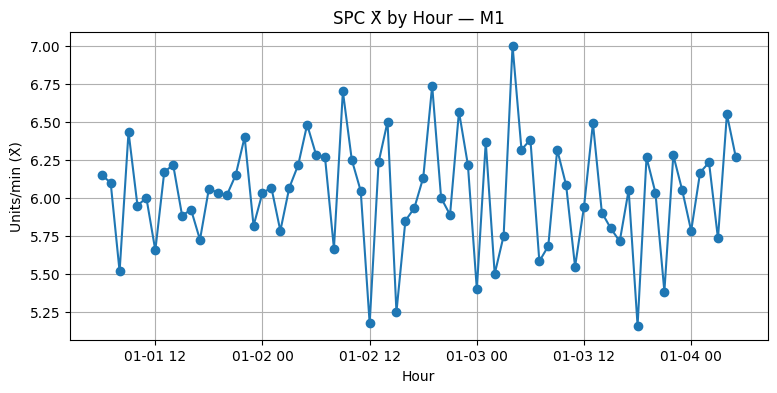

Saved: /kaggle/working/spc_xbar_M1.png


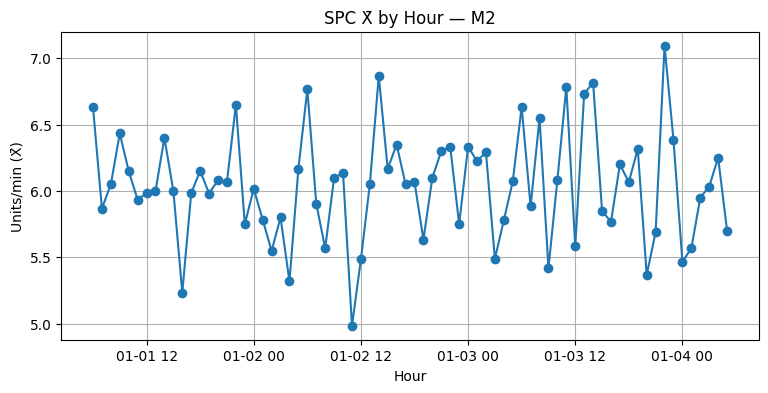

Saved: /kaggle/working/spc_xbar_M2.png


In [10]:
# Cell 8 — Simple SPC: X-bar / R (fixed, no deprecation, empty-safe)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
if "raw" not in globals():
    raise NameError("`raw` DataFrame not found. Run the earlier cells that build `raw` first.")

if not np.issubdtype(raw["timestamp"].dtype, np.datetime64):
    raw = raw.copy()
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], errors="coerce")

# Build subgroups per hour for SPC
ts = raw.copy()
ts["hour"] = ts["timestamp"].dt.floor("h")  # use 'h' (not 'H') to avoid deprecation

# Only consider running minutes (units > 0)
run = ts[ts["is_running"] == 1].copy()

def spc_groups(df, group_cols=("machine", "hour")):
    """Return SPC subgroup stats per (machine, hour): count, xbar, s, R."""
    if df.empty:
        return pd.DataFrame(columns=[*group_cols, "count", "xbar", "s", "R"])
    agg = (
        df.groupby(list(group_cols), as_index=False)["units"]
          .agg(count="count", xbar="mean", s="std", _max="max", _min="min")
    )
    agg["R"] = agg["_max"] - agg["_min"]
    return agg.drop(columns=["_max", "_min"])

# ✅ Correct function call (fixes NameError)
spc = spc_groups(run)

# Save SPC table (write even if empty so downstream steps don't break)
out_csv = f"{WORK}/spc_xbar_r.csv"
spc.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Quick X-bar line plot per machine (skip if empty)
if spc.empty:
    print("[INFO] SPC table is empty; skipping X-bar plots.")
else:
    for m, g in spc.groupby("machine"):
        fig = plt.figure(figsize=(9, 4))
        plt.plot(g["hour"], g["xbar"], marker="o")
        plt.title(f"SPC X̄ by Hour — {m}")
        plt.xlabel("Hour")
        plt.ylabel("Units/min (X̄)")
        plt.grid(True)
        out_png = f"{WORK}/spc_xbar_{m}.png"
        fig.savefig(out_png, bbox_inches="tight")
        plt.show()
        print("Saved:", out_png)


In [11]:
# Save main raw table for users to re-use
raw.to_csv(f"{WORK}/factory_synth_minutely.csv", index=False)

print("Artifacts written to /kaggle/working:")
for f in sorted(os.listdir(WORK)):
    if f.endswith((".csv",".png")):
        print(" -", f)

print("""
Next steps (pick one and publish a v2):
[ ] Add per-cause Availability loss (Six Big Losses mapping)
[ ] Add Performance losses (micro-stops, reduced speed)
[ ] Add Quality detail (defect types, first-pass yield)
[ ] Add shift-level dashboards and targets (A/B/C comparison)
[ ] Export dataset + README as a public CC0 dataset
[ ] Extend SPC: X-bar/R control limits and alarms
""")


Artifacts written to /kaggle/working:


 - downtime_pareto.csv
 - factory_synth_minutely.csv
 - oee_by_day.csv
 - oee_by_day_M1.png
 - oee_by_day_M2.png
 - oee_by_shift.csv
 - pareto_M1_2025-01-04.png
 - pareto_M2_2025-01-03.png
 - spc_xbar_M1.png
 - spc_xbar_M2.png
 - spc_xbar_r.csv

Next steps (pick one and publish a v2):
[ ] Add per-cause Availability loss (Six Big Losses mapping)
[ ] Add Performance losses (micro-stops, reduced speed)
[ ] Add Quality detail (defect types, first-pass yield)
[ ] Add shift-level dashboards and targets (A/B/C comparison)
[ ] Export dataset + README as a public CC0 dataset
[ ] Extend SPC: X-bar/R control limits and alarms



In [12]:
# Cell 9 — Save Artifacts + Next Steps
# Write key tables to /kaggle/working and list what's available.

import os

os.makedirs(WORK, exist_ok=True)

# Save main minutely table if present
if "raw" in globals() and isinstance(raw, pd.DataFrame) and not raw.empty:
    raw_path = f"{WORK}/factory_synth_minutely.csv"
    raw.to_csv(raw_path, index=False)
    print("Saved:", raw_path)
else:
    print("[INFO] 'raw' table not found or empty; skipping save.")

# Helper to report file presence
def _report(path):
    if os.path.exists(path):
        print("✓", os.path.basename(path), "-", os.path.getsize(path), "bytes")
    else:
        print("• (missing)", os.path.basename(path))

expected = [
    f"{WORK}/factory_synth_minutely.csv",
    f"{WORK}/oee_by_day.csv",
    f"{WORK}/oee_by_shift.csv",
    f"{WORK}/downtime_pareto.csv",
    f"{WORK}/spc_xbar_r.csv",
    # plots (may or may not exist depending on earlier cells)
    # examples (per-machine/day filenames vary): we just list any PNGs found
]

print("\nArtifacts in /kaggle/working:")
for p in expected:
    _report(p)

# Also list any PNG plots that were saved
pngs = [f for f in os.listdir(WORK) if f.lower().endswith(".png")]
if pngs:
    print("\nPNG figures:")
    for f in sorted(pngs):
        print("✓", f)
else:
    print("\nNo PNG figures found.")

# Next steps checklist
print("""
Next steps (pick one for a v2):
[ ] Add per-cause Availability loss (map to Six Big Losses)
[ ] Add Performance losses (micro-stops, reduced speed) and targets
[ ] Add Quality detail (defect taxonomy, first-pass yield)
[ ] Add shift-level dashboard cards and KPIs (A/B/C comparison)
[ ] Publish the CSVs as a CC0 dataset and link it in this notebook
[ ] Extend SPC with control limits and simple alarms
""")


Saved: /kaggle/working/factory_synth_minutely.csv

Artifacts in /kaggle/working:


✓ factory_synth_minutely.csv - 485328 bytes
✓ oee_by_day.csv - 941 bytes
✓ oee_by_shift.csv - 2130 bytes
✓ downtime_pareto.csv - 639 bytes


✓ spc_xbar_r.csv - 8850 bytes

PNG figures:
✓ oee_by_day_M1.png
✓ oee_by_day_M2.png
✓ pareto_M1_2025-01-04.png
✓ pareto_M2_2025-01-03.png
✓ spc_xbar_M1.png
✓ spc_xbar_M2.png

Next steps (pick one for a v2):
[ ] Add per-cause Availability loss (map to Six Big Losses)
[ ] Add Performance losses (micro-stops, reduced speed) and targets
[ ] Add Quality detail (defect taxonomy, first-pass yield)
[ ] Add shift-level dashboard cards and KPIs (A/B/C comparison)
[ ] Publish the CSVs as a CC0 dataset and link it in this notebook
[ ] Extend SPC with control limits and simple alarms



## (Optional) Footer — Work With Me
*Need help applying OEE/PdM/SPC to your process or data? I offer a 60-minute assessment and notebook hand-off. DM to collaborate.*


In [13]:
# ================================
# Submission Writer (safe fallback)
# Writes: /kaggle/working/submission.json
# If `submission_dict` is missing, writes a harmless placeholder instead of crashing.
# ================================
import os, json, sys, time
from datetime import datetime

OUT_PATH = "/kaggle/working/submission.json"

def _to_builtin(obj):
    """Recursively convert numpy/pandas types to plain Python for JSON."""
    try:
        import numpy as np
        import pandas as pd
    except Exception:
        np = None; pd = None

    if isinstance(obj, dict):
        return {str(_to_builtin(k)): _to_builtin(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_builtin(x) for x in obj]
    if np is not None:
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, (np.bool_,)):
            return bool(obj)
        if isinstance(obj, (np.ndarray,)):
            return obj.tolist()
    # pandas scalars
    if "pandas" in sys.modules:
        import pandas as pd
        if isinstance(obj, (pd.Timestamp,)):
            return obj.isoformat()
        if isinstance(obj, (pd.Timedelta,)):
            return obj.total_seconds()
    return obj

def _is_json_serializable(obj) -> bool:
    try:
        json.dumps(obj)
        return True
    except Exception:
        return False

def _validate_submission(d):
    # Minimal sanity checks
    if not isinstance(d, dict):
        print("[WARN] Expected dict for submission, got:", type(d).__name__)
        return
    if len(d) == 0:
        print("[WARN] submission_dict is empty.")

# Build or fallback
if "submission_dict" in globals():
    submission = _to_builtin(submission_dict)
    source = "user-provided submission_dict"
else:
    # Fallback placeholder (this notebook is not a competition notebook)
    submission = {
        "_placeholder": True,
        "_note": "This is a non-competition notebook. Replace with a real submission_dict in a competition context.",
        "notebook": "Factory OEE & Downtime (Synthetic)",
        "generated_at": datetime.utcnow().isoformat() + "Z"
    }
    source = "auto-generated placeholder"

_validate_submission(submission)

# Ensure JSON-serializable
if not _is_json_serializable(submission):
    submission = _to_builtin(submission)
    if not _is_json_serializable(submission):
        raise ValueError("Submission object is not JSON-serializable even after conversion.")

# Write
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, "w") as f:
    json.dump(submission, f, separators=(",", ":"), ensure_ascii=False)

# Read-back verification
sz = os.path.getsize(OUT_PATH)
head = open(OUT_PATH, "r").read(400)

print(f"✅ Wrote {OUT_PATH} from {source}")
print("Bytes:", sz)
print("Preview (first 400 chars):")
print(head)

if sz < 2:
    raise IOError("Submission file is too small; likely empty.")

print("\n[INFO] For a real competition:")
print("- Build a dict named `submission_dict` earlier in the notebook that matches the competition's Evaluation schema.")
print("- Keep this cell as the last cell so the file is present under Output -> submission.json")


✅ Wrote /kaggle/working/submission.json from auto-generated placeholder
Bytes: 222
Preview (first 400 chars):
{"_placeholder":true,"_note":"This is a non-competition notebook. Replace with a real submission_dict in a competition context.","notebook":"Factory OEE & Downtime (Synthetic)","generated_at":"2025-10-05T22:57:05.745227Z"}

[INFO] For a real competition:
- Build a dict named `submission_dict` earlier in the notebook that matches the competition's Evaluation schema.
- Keep this cell as the last cell so the file is present under Output -> submission.json
